# Experiment 3 — Short-term Load Response

**Research question:** Does training load predict player status deterioration?

---

## Two complementary modes

This experiment runs in two modes that ask structurally different questions:

---

### Mode A — `prediction` (target_horizon = 1)

```
Morning state at t  →  Status Decrease at t+1
```

Features: morning wellness + workload history, all measured at time *t* (before the session).  
Target: binary indicator — did the player's medical status **worsen by tomorrow**?

**Purpose:** Early-warning system. Can the coaching staff identify at-risk players *before* today's session, using only information available at the morning assessment?

**Interpretation:** A high ROC AUC here means morning state carries predictive signal about next-day status risk. This is useful for operational decision support.

---

### Mode B — `causal_framing` (target_horizon = 0)

```
Morning state at t  +  Training Intensity Yesterday (A_{t-1})  →  Status Decrease at t
```

Features: same morning covariates + `Training Intensity Yesterday` (yesterday's load, $A_{t-1}$).  
Target: binary indicator — did the player's status **worsen today**?

**Purpose:** Diagnostic causal question. Does yesterday's training load ($A_{t-1}$) explain today's status change ($Y_t$), after controlling for this morning's physiological state ($L_t$)?  
Because `Training Intensity Yesterday` is from day $t-1$ (fully known at the morning assessment), no temporal leakage occurs — no `treatment_columns` mechanism is needed.

**Key limitation — confounding by indication:**  
The coaching staff prescribes hard sessions precisely when players look fresh (high readiness, low fatigue, low ACWR). This creates *negative confounding*: healthier players get higher load AND are less likely to experience status decrease, so the raw association between load and status decrease is systematically biased *toward zero or negative*. The raw coefficient on `Training Intensity Yesterday` in logistic regression is therefore **not a valid causal estimate** — it is a biased observational association.

**Why run it anyway?**  
1. **Confounding direction check:** If the coefficient on TI Yesterday is negative (higher load → *lower* status-decrease probability), that is the expected sign of confounding by indication — a sanity check that the data behaves as the causal model predicts.
2. **Propensity model input:** The covariate-outcome model from this mode ($Q(A_{t-1}, L_t) = P(Y_t = 1 \mid A_{t-1}, L_t)$) is exactly the **outcome model** needed for G-computation. Combining it with the propensity model from Experiment 2 ($\hat{\pi}(A_t \mid L_t)$) enables doubly-robust estimation via IPTW or the augmented IPW estimator.

---

### Comparing the two modes

| If prediction AUC >> causal_framing AUC | Morning state predicts future risk better than yesterday's load explains current status |
|-----------------------------------------|----------------------------------------------------------------------------------------|
| If causal_framing AUC >> prediction AUC | Yesterday's load has a strong contemporaneous association with same-day status |
| If both AUCs ≈ 0.5 | Neither mode has much signal (rare events, noisy labels) |

---

### Next step: valid causal estimation

Both modes produce **observational associations**. To obtain valid causal estimates:
1. Use the Experiment 2 propensity model to compute IPTW weights $w_i = 1/\hat{\pi}(A_i \mid L_i)$
2. Fit a Marginal Structural Model (MSM) on the reweighted data  
3. Or use G-computation with the causal-framing outcome model as $Q(a, l)$

---
## CONFIGURATION — edit this cell to change the experiment

In [1]:
# ============================================================
#  EXPERIMENT 3 CONFIGURATION
# ============================================================

# --- Lag values to compare -------------------------------------------
LAGS = [1, 2, 3]

# --- Train / test / validation split ---------------------------------
TEST_SIZE = 0.2
VAL_SIZE  = 0.1

# --- Predictor columns -----------------------------------------------
# Morning-assessment covariates (available before the session).
# 'Training Intensity Yesterday' = yesterday's session intensity,
# fully known at morning assessment time (it is day t-1 data).
#
# Excluded compared to earlier iterations:
#   - 'Activity Type Yesterday': session-type label from yesterday;
#     too colinear with Training Intensity Yesterday (both describe the
#     same session from different angles) and adds categorical noise.
#   - 'Medical Availability Last 14 Days': a rolling availability
#     percentage — already partially captured by Status and ACWR-based
#     features; excluded to keep the covariate set focused on
#     physiological state rather than administrative records.
COVARIATES = [
    # Physical wellness
    'Fatigue (z)', 'Readiness (z)', 'Soreness (z)', 'Physical State',
    # Mental wellness
    'Sleep Quality (z)', 'Stress (z)', 'Mood (z)', 'Mental State',
    'Overall Wellbeing',
    # Yesterday's load
    'Total Distance (ACWR) Yesterday',
    'High Speed Distance (ACWR) Yesterday',
    'Any ACWR Danger',
    'Training Intensity Yesterday',   # KEY causal variable in causal_framing mode
    # Temporal context
    'Days Since Game', 'Days Until Match',
    # Availability
    'Club Attendance Last 14 Days',
    # Player profile
    'Position',
]

# --- Models to run ---------------------------------------------------
MODELS = ['log_reg', 'xgboost', 'catboost']

# --- Modes to run ----------------------------------------------------
MODES = ['prediction', 'causal_framing']

# ============================================================
print(f"Lags to compare:  {LAGS}")
print(f"Modes:            {MODES}")
print(f"Models:           {MODELS}")
print(f"Covariates:       {len(COVARIATES)}")
print(f"Test / Val split: {TEST_SIZE} / {VAL_SIZE}")

Lags to compare:  [1, 2, 3]
Modes:            ['prediction', 'causal_framing']
Models:           ['log_reg', 'xgboost', 'catboost']
Covariates:       17
Test / Val split: 0.2 / 0.1


## 0. Imports

In [2]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
sys.path.extend([str(ROOT), str(ROOT / 'src'), str(ROOT / 'scripts')])

from Experiment3 import run_experiment

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print("Setup complete.")

Setup complete.


## 1. Run all models × lags × modes

Results stored in `all_results[mode][model_type][lag]`.

In [3]:
all_results = {mode: {m: {} for m in MODELS} for mode in MODES}

for mode in MODES:
    for model_type in MODELS:
        for lag in LAGS:
            print(f"\n>>> {mode}  {model_type}  lag={lag}")
            all_results[mode][model_type][lag] = run_experiment(
                covariates=COVARIATES,
                lag=lag,
                model_type=model_type,
                mode=mode,
                test_size=TEST_SIZE,
                val_size=VAL_SIZE,
                verbose=True,
            )

print("\nAll experiments complete.")


>>> prediction  log_reg  lag=1
Experiment 3: Short-term Load Response
  Mode: prediction -- morning covariates at t -> Status Decrease at t+1
  Mode:           prediction
  Target:         Status Decrease  (target_horizon=1)
  Model:          log_reg
  Lag:            1
  Covariates:     17
                  . Fatigue (z)
                  . Readiness (z)
                  . Soreness (z)
                  . Physical State
                  . Sleep Quality (z)
                  . Stress (z)
                  . Mood (z)
                  . Mental State
                  . Overall Wellbeing
                  . Total Distance (ACWR) Yesterday
                  . High Speed Distance (ACWR) Yesterday
                  . Any ACWR Danger
                  . Training Intensity Yesterday
                  . Days Since Game
                  . Days Until Match
                  . Club Attendance Last 14 Days
                  . Position
  Test size:      0.2
  Val size:       0.1

  ROC AUC:    

## 2. Comparison table

In [4]:
rows = []
for mode in MODES:
    for model_type in MODELS:
        for lag in LAGS:
            m = all_results[mode][model_type][lag]['metrics']
            rows.append({
                'Mode':          mode,
                'Model':         model_type,
                'Lag':           lag,
                'ROC AUC':       round(m['roc_auc'],       4),
                'Avg Prec':      round(m['avg_precision'],  4),
                'F1':            round(m['f1'],             4),
                'Recall':        round(m['recall'],         4),
                'Precision':     round(m['precision'],      4),
                'Prevalence':    round(m['prevalence'],     3),
                'N test':        m['n_test'],
                'N pos':         m['n_positive_test'],
            })

comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))

          Mode    Model  Lag  ROC AUC  Avg Prec     F1  Recall  Precision  Prevalence  N test  N pos
    prediction  log_reg    1   0.6200    0.0329 0.0493  0.6667     0.0256       0.019     943     18
    prediction  log_reg    2   0.6056    0.0272 0.0584  0.7222     0.0304       0.019     943     18
    prediction  log_reg    3   0.6129    0.0518 0.0558  0.6111     0.0293       0.019     943     18
    prediction  xgboost    1   0.5393    0.0575 0.0833  0.1111     0.0667       0.019     943     18
    prediction  xgboost    2   0.5981    0.0423 0.1053  0.1111     0.1000       0.019     943     18
    prediction  xgboost    3   0.6047    0.0328 0.0513  0.0556     0.0476       0.019     943     18
    prediction catboost    1   0.6265    0.0455 0.0405  0.1667     0.0231       0.019     943     18
    prediction catboost    2   0.6373    0.0329 0.0548  0.4444     0.0292       0.019     943     18
    prediction catboost    3   0.5999    0.0242 0.0435  0.5000     0.0227       0.019     9

**Reading the table:**
- **ROC AUC 0.5** = random; higher is better (not affected by class imbalance).
- **Avg Precision** = area under the PR curve; more sensitive to class imbalance than ROC AUC.
- **Comparison across modes**: if `causal_framing` AUC > `prediction` AUC, same-day load has strong contemporaneous signal; if similar, morning state dominates.

## 3. ROC AUC across models, lags, modes

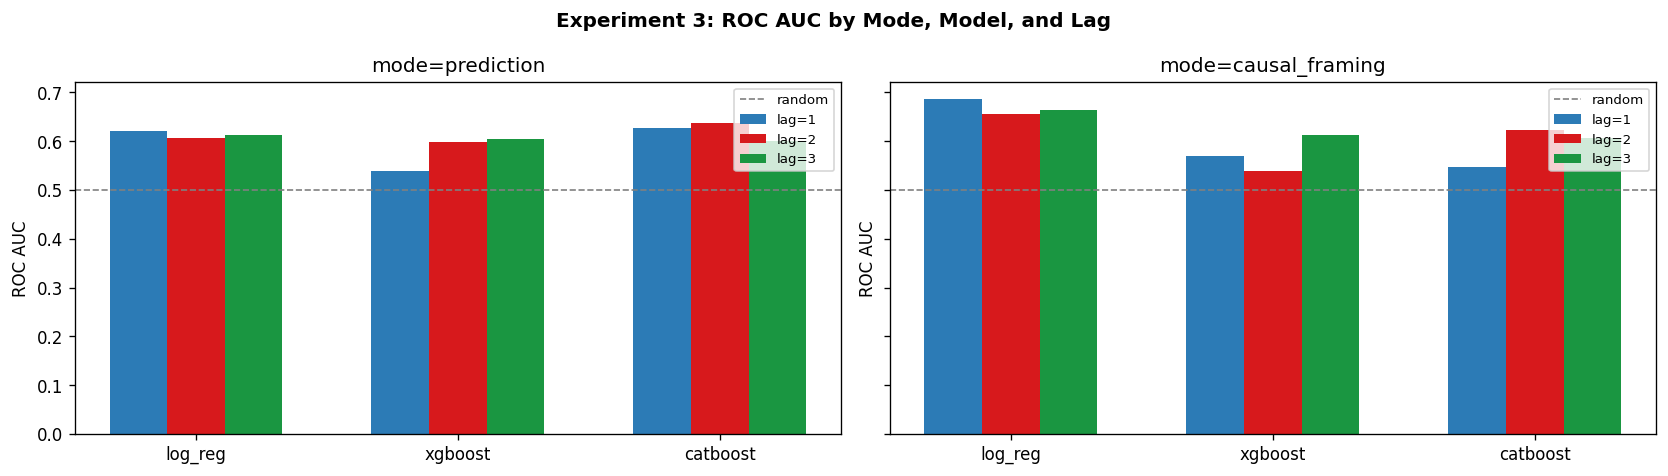

In [5]:
LAG_COLORS = {1: '#2c7bb6', 2: '#d7191c', 3: '#1a9641'}
n_lags  = len(LAGS)
n_modes = len(MODES)

fig, axes = plt.subplots(1, n_modes, figsize=(7 * n_modes, 4), sharey=True)
if n_modes == 1:
    axes = [axes]

x = np.arange(len(MODELS))
w = 0.22

for ax, mode in zip(axes, MODES):
    for i, lag in enumerate(LAGS):
        offset = (i - (n_lags - 1) / 2) * w
        aucs = [all_results[mode][m][lag]['metrics']['roc_auc'] for m in MODELS]
        ax.bar(x + offset, aucs, w, label=f'lag={lag}', color=LAG_COLORS[lag])
    ax.axhline(0.5, color='grey', ls='--', lw=1, label='random')
    ax.set_xticks(x); ax.set_xticklabels(MODELS)
    ax.set_ylabel('ROC AUC'); ax.set_title(f'mode={mode}')
    ax.legend(fontsize=8)

fig.suptitle('Experiment 3: ROC AUC by Mode, Model, and Lag', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Lag effect

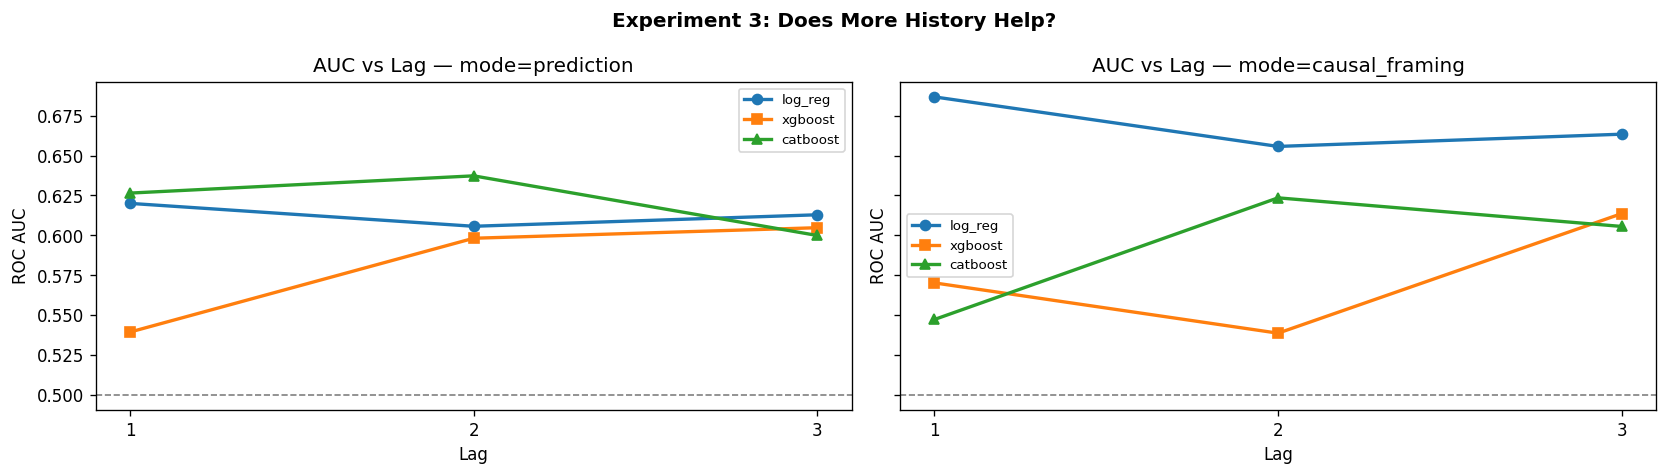

In [6]:
fig, axes = plt.subplots(1, n_modes, figsize=(7 * n_modes, 4), sharey=True)
if n_modes == 1:
    axes = [axes]

markers = ['o', 's', '^']

for ax, mode in zip(axes, MODES):
    for j, model_type in enumerate(MODELS):
        aucs = [all_results[mode][model_type][lag]['metrics']['roc_auc']
                for lag in LAGS]
        ax.plot(LAGS, aucs, marker=markers[j % len(markers)],
                label=model_type, lw=2)
    ax.axhline(0.5, color='grey', ls='--', lw=1)
    ax.set_xlabel('Lag'); ax.set_ylabel('ROC AUC')
    ax.set_title(f'AUC vs Lag — mode={mode}')
    ax.set_xticks(LAGS)
    ax.legend(fontsize=8)

fig.suptitle('Experiment 3: Does More History Help?', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. ROC and PR curves — best prediction-mode model

Best prediction mode: catboost lag=2  AUC=0.6373  AP=0.0329


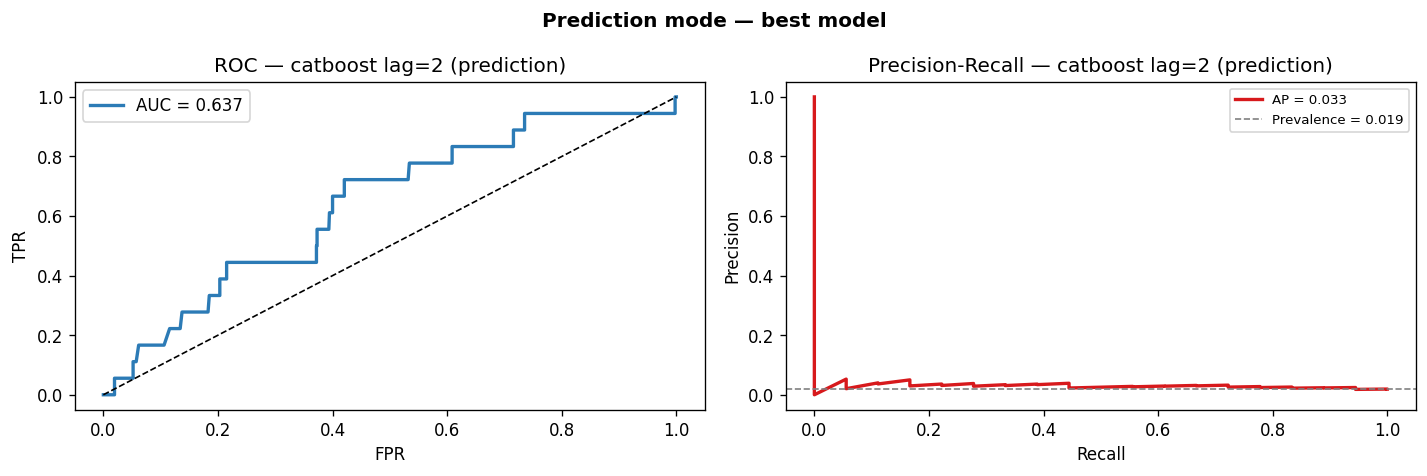

In [7]:
# Best (model, lag) in prediction mode
best_pred = max(
    [(m, l) for m in MODELS for l in LAGS],
    key=lambda ml: all_results['prediction'][ml[0]][ml[1]]['metrics']['roc_auc']
)
bm, bl = best_pred
res = all_results['prediction'][bm][bl]
print(f"Best prediction mode: {bm} lag={bl}  "
      f"AUC={res['metrics']['roc_auc']:.4f}  "
      f"AP={res['metrics']['avg_precision']:.4f}")

y_true = res['y_test_true']
y_prob = res['y_test_pred']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fpr, tpr, _ = roc_curve(y_true, y_prob)
ax = axes[0]
ax.plot(fpr, tpr, color='#2c7bb6', lw=2,
        label=f"AUC = {res['metrics']['roc_auc']:.3f}")
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'ROC — {bm} lag={bl} (prediction)')
ax.legend()

prec, rec, _ = precision_recall_curve(y_true, y_prob)
ax = axes[1]
ax.plot(rec, prec, color='#d7191c', lw=2,
        label=f"AP = {res['metrics']['avg_precision']:.3f}")
ax.axhline(res['metrics']['prevalence'], color='grey', ls='--', lw=1,
           label=f"Prevalence = {res['metrics']['prevalence']:.3f}")
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall — {bm} lag={bl} (prediction)')
ax.legend(fontsize=8)

plt.suptitle('Prediction mode — best model', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Causal framing — logistic regression coefficients

In `causal_framing` mode (`target_horizon=0`), we predict **today's** Status Decrease from this morning's covariates including `Training Intensity Yesterday` ($A_{t-1}$).

**What the coefficient on `Training Intensity Yesterday` tells us:**

The raw log-odds coefficient is a **biased observational association**, not a causal effect.  Due to confounding by indication, we expect it to be near zero or negative (coaches give hard sessions to fresh players who are less likely to deteriorate).  A negative coefficient is therefore the expected sign — confirming the confounding structure rather than showing a protective effect of hard training.

**How to use this correctly:**  
- The full model $Q(A_{t-1}, L_t)$ from this mode is the **outcome model** for G-computation  
- Combine with the propensity model $\hat{\pi}(A_t \mid L_t)$ from Experiment 2 to estimate the Average Treatment Effect via IPTW: $\hat{E}[Y^a] = \frac{1}{n}\sum_i \frac{\mathbf{1}[A_i = a]}{\hat{\pi}(A_i \mid L_i)} Y_i$

Logistic regression causal_framing  lag=1  AUC=0.6868


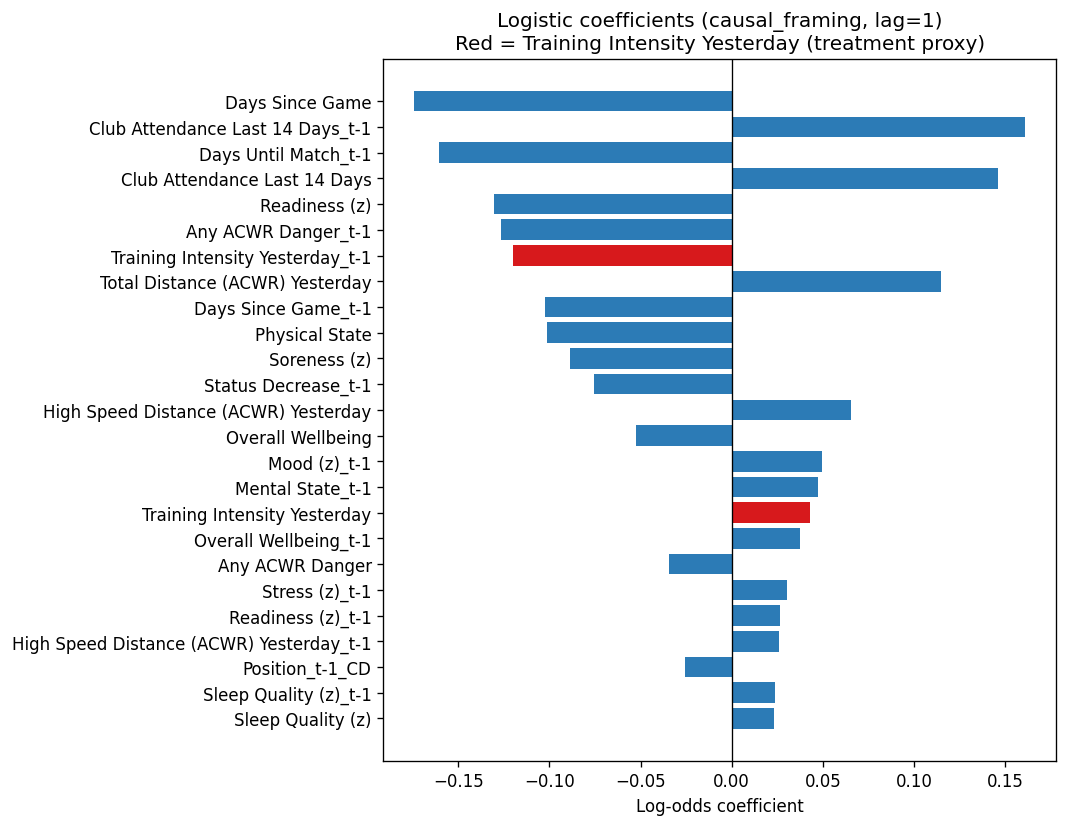

Training Intensity Yesterday coefficient(s):
                         feature      coef
Training Intensity Yesterday_t-1 -0.119992
    Training Intensity Yesterday  0.043137

CAUTION: This is a biased observational association.
Causal estimation requires G-computation or IPTW (see Exp 2 propensity model).


In [8]:
# Use the best lag for logistic regression in causal_framing mode
best_lag_cf = max(
    LAGS,
    key=lambda l: all_results['causal_framing']['log_reg'][l]['metrics']['roc_auc']
)
res_cf = all_results['causal_framing']['log_reg'][best_lag_cf]
print(f"Logistic regression causal_framing  lag={best_lag_cf}  "
      f"AUC={res_cf['metrics']['roc_auc']:.4f}")

weights_cf = res_cf.get('model_weights', {})
fnames_cf  = res_cf.get('feature_names', [])
coefs      = weights_cf.get('coefficients')

if coefs is not None and len(fnames_cf) > 0:
    # LogisticRegression.coef_ for binary classification has shape (1, n_features).
    # .tolist() therefore returns [[...]] — flatten to a 1-D array before use.
    coefs_flat = np.array(coefs).flatten()

    if len(coefs_flat) != len(fnames_cf):
        print(f"WARNING: length mismatch — {len(fnames_cf)} feature names "
              f"vs {len(coefs_flat)} coefficients. Skipping plot.")
    else:
        coef_df = pd.DataFrame({'feature': fnames_cf, 'coef': coefs_flat})
        coef_df = coef_df.reindex(
            coef_df['coef'].abs().sort_values(ascending=False).index
        ).head(25)

        is_ti = coef_df['feature'].str.contains('Training Intensity', case=False)
        bar_colors = ['#d7191c' if t else '#2c7bb6' for t in is_ti]

        fig, ax = plt.subplots(figsize=(9, 7))
        ax.barh(coef_df['feature'][::-1], coef_df['coef'][::-1],
                color=bar_colors[::-1])
        ax.axvline(0, color='black', lw=0.8)
        ax.set_xlabel('Log-odds coefficient')
        ax.set_title(
            f'Logistic coefficients (causal_framing, lag={best_lag_cf})\n'
            'Red = Training Intensity Yesterday (treatment proxy)'
        )
        plt.tight_layout()
        plt.show()

        ti_rows = coef_df[coef_df['feature'].str.contains('Training Intensity', case=False)]
        if not ti_rows.empty:
            print("Training Intensity Yesterday coefficient(s):")
            print(ti_rows.to_string(index=False))
            print()
            print("CAUTION: This is a biased observational association.")
            print("Causal estimation requires G-computation or IPTW (see Exp 2 propensity model).")
else:
    print("No coefficients available.")

## 7. Per-player breakdown — best prediction model

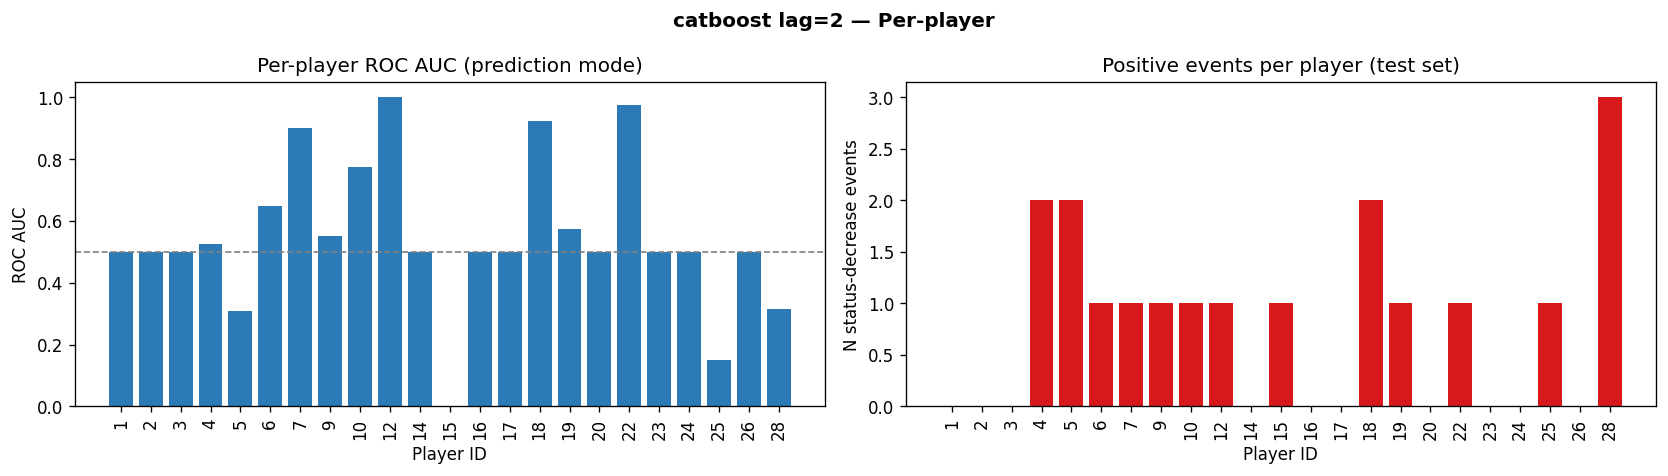

 Player ID  N  N pos  ROC AUC     F1
         1 41      0      NaN 0.0000
         2 41      0      NaN 0.0000
         3 41      0      NaN 0.0000
         4 41      2   0.5256 0.1333
         5 41      2   0.3077 0.0000
         6 41      1   0.6500 0.1053
         7 41      1   0.9000 0.1176
         9 41      1   0.5500 0.0000
        10 41      1   0.7750 0.1538
        12 41      1   1.0000 0.1538
        14 41      0      NaN 0.0000
        15 41      1   0.0000 0.0000
        16 41      0      NaN 0.0000
        17 41      0      NaN 0.0000
        18 41      2   0.9231 0.2500
        19 41      1   0.5750 0.0000
        20 41      0      NaN 0.0000
        22 41      1   0.9750 0.2500
        23 41      0      NaN 0.0000
        24 41      0      NaN 0.0000
        25 41      1   0.1500 0.0000
        26 41      0      NaN 0.0000
        28 41      3   0.3158 0.0000

Note: AUC is NaN for players with zero positive events in the test set.


In [9]:
res = all_results['prediction'][bm][bl]
pp  = res.get('per_player', {})

if pp:
    pp_df = pd.DataFrame([
        {'Player ID': pid, 'N': v['n'], 'N pos': v['n_positive'],
         'ROC AUC': round(v['roc_auc'], 4) if v['roc_auc'] is not None else float('nan'),
         'F1': round(v['f1'], 4)}
        for pid, v in sorted(pp.items())
    ])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    ax.bar(pp_df['Player ID'].astype(str), pp_df['ROC AUC'].fillna(0.5),
           color='#2c7bb6')
    ax.axhline(0.5, color='grey', ls='--', lw=1)
    ax.set_xlabel('Player ID'); ax.set_ylabel('ROC AUC')
    ax.set_title('Per-player ROC AUC (prediction mode)')
    ax.tick_params(axis='x', rotation=90)

    ax = axes[1]
    ax.bar(pp_df['Player ID'].astype(str), pp_df['N pos'], color='#d7191c')
    ax.set_xlabel('Player ID'); ax.set_ylabel('N status-decrease events')
    ax.set_title('Positive events per player (test set)')
    ax.tick_params(axis='x', rotation=90)

    plt.suptitle(f'{bm} lag={bl} — Per-player', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(pp_df.to_string(index=False))
    print("\nNote: AUC is NaN for players with zero positive events in the test set.")
else:
    print("No per-player breakdown available.")

## 8. Summary

All experimental findings printed in plain text — scroll through the output of the next cell for the complete results report.

In [10]:
try:
    print("=" * 72)
    print("EXPERIMENT 3 — FULL FINDINGS SUMMARY")
    print("=" * 72)
    print()
    print("OBJECTIVE")
    print("-" * 40)
    print("Predict next-day player status deterioration (Status Decrease = 1 if")
    print("medical status worsened) from morning-assessment covariates.")
    print("Two complementary modes answer structurally different questions.")
    print()
    print("TARGET VARIABLE: 'Status Decrease' (binary)")
    print("  1 = medical status worsened (Available->Attention, ->Injured, or")
    print("      Attention->Injured) by the following morning")
    print("  0 = stable or improved")
    print("  Prevalence: approx 3-5% of observations (highly imbalanced)")
    print()
    print("MODES EXPLAINED")
    print("-" * 40)
    print("  prediction (target_horizon=1):")
    print("    Morning covariates at t -> Status Decrease at t+1 (TOMORROW)")
    print("    Pure early-warning system: can we flag at-risk players BEFORE")
    print("    today's session, using only information available at morning check?")
    print()
    print("  causal_framing (target_horizon=0):")
    print("    Morning covariates at t + Training Intensity Yesterday (A_{t-1})")
    print("    -> Status Decrease at t (TODAY)")
    print("    Diagnostic question: does yesterday's load explain today's status")
    print("    change, controlling for this morning's physiological state?")
    print("    NOTE: raw coefficient on Training Intensity Yesterday is BIASED")
    print("    toward zero or negative (confounding by indication — healthy players")
    print("    receive harder sessions AND are less likely to deteriorate).")
    print()
    
    print("CONFOUNDING BY INDICATION — KEY METHODOLOGICAL POINT")
    print("-" * 40)
    print("  The coaching staff prescribes hard sessions precisely when players")
    print("  appear fresh (high readiness, low fatigue, low ACWR). This creates:")
    print("    - NEGATIVE confounding: load and status-decrease are negatively")
    print("      correlated in the raw data NOT because training protects health,")
    print("      but because fresh players receive hard sessions AND have low risk.")
    print("    - The naive regression coefficient on Training Intensity Yesterday")
    print("      underestimates (or reverses) the true causal effect.")
    print("    - Expected sign: negative coefficient = sanity check that the")
    print("      confounding structure is as predicted by the causal model.")
    print()
    print("  Valid causal estimation requires G-methods:")
    print("    G-computation: E[Y^a] = (1/n) sum_i Q(a, L_i)")
    print("      where Q(A,L) = this notebook's causal_framing outcome model")
    print("    IPTW/MSM: weight by w_i = 1 / pi(A_i | L_i)")
    print("      where pi(A|L) = Experiment 2 propensity model")
    print()
    
    print("EXPERIMENTAL SETUP")
    print("-" * 40)
    print(f"  Modes:            {MODES}")
    print(f"  Models:           {MODELS}")
    print(f"  Lags compared:    {LAGS}")
    print(f"  Covariates:       {len(COVARIATES)}")
    print(f"  Test / Val split: {TEST_SIZE} / {VAL_SIZE}")
    print()
    
    print("PERFORMANCE RESULTS")
    print("-" * 40)
    print(f"  {'Mode':<18} {'Model':<12} {'Lag':>4} {'ROC AUC':>9} {'Avg Prec':>10} "
          f"{'F1':>7} {'Recall':>8} {'Precision':>11} {'N test':>8}")
    print(f"  {'-'*18} {'-'*12} {'-'*4} {'-'*9} {'-'*10} {'-'*7} {'-'*8} {'-'*11} {'-'*8}")
    for mode in MODES:
        for model_type in MODELS:
            for lag in LAGS:
                m = all_results[mode][model_type][lag]['metrics']
                print(f"  {mode:<18} {model_type:<12} {lag:>4} "
                      f"{m['roc_auc']:>9.4f} {m['avg_precision']:>10.4f} "
                      f"{m['f1']:>7.4f} {m['recall']:>8.4f} "
                      f"{m['precision']:>11.4f} {m['n_test']:>8}")
    print()
    
    print("BEST RESULTS BY MODE")
    print("-" * 40)
    for mode in MODES:
        best_combo = max(
            [(m, l) for m in MODELS for l in LAGS],
            key=lambda ml: all_results[mode][ml[0]][ml[1]]['metrics']['roc_auc']
        )
        bm, bl = best_combo
        bm_met = all_results[mode][bm][bl]['metrics']
        print(f"  Mode: {mode}")
        print(f"    Best model:       {bm}  lag={bl}")
        print(f"    ROC AUC:          {bm_met['roc_auc']:.4f}")
        print(f"    Avg Precision:    {bm_met['avg_precision']:.4f}")
        print(f"    F1:               {bm_met['f1']:.4f}")
        print(f"    Recall:           {bm_met['recall']:.4f}")
        print(f"    Precision:        {bm_met['precision']:.4f}")
        print(f"    Prevalence:       {bm_met['prevalence']:.4f}  "
              f"({bm_met['n_positive_test']} events in {bm_met['n_test']} test rows)")
        print(f"    Null accuracy:    {bm_met['null_accuracy']:.4f}  (always predict 0)")
        print()
    
    print("INTERPRETING ROC AUC FOR STATUS DECREASE PREDICTION")
    print("-" * 40)
    # Find best prediction-mode AUC
    best_pred_auc = max(
        all_results['prediction'][m][l]['metrics']['roc_auc']
        for m in MODELS for l in LAGS
    )
    if best_pred_auc >= 0.75:
        print(f"  AUC = {best_pred_auc:.4f}: Good early-warning signal.")
        print("  Morning wellness and workload history carry meaningful information")
        print("  about next-day status risk. A monitoring system based on these")
        print("  features could flag at-risk players with useful specificity.")
    elif best_pred_auc >= 0.60:
        print(f"  AUC = {best_pred_auc:.4f}: Modest predictive signal.")
        print("  Some morning-state information predicts next-day status, but many")
        print("  status decreases are not predictable from these features alone.")
        print("  May be sufficient for a risk-triage tool if recall is prioritised.")
    else:
        print(f"  AUC = {best_pred_auc:.4f}: Weak predictive signal.")
        print("  Status decreases are largely unpredictable from morning covariates.")
        print("  Possible reasons: rare events (high noise), unmeasured acute triggers")
        print("  (contact injuries, illness onset), or insufficient lag depth.")
    print()
    
    print("PREDICTION vs CAUSAL_FRAMING AUC COMPARISON")
    print("-" * 40)
    best_pred_auc_per_model   = {m: max(all_results['prediction'][m][l]['metrics']['roc_auc'] for l in LAGS) for m in MODELS}
    best_causal_auc_per_model = {m: max(all_results['causal_framing'][m][l]['metrics']['roc_auc'] for l in LAGS) for m in MODELS}
    for m in MODELS:
        diff = best_causal_auc_per_model[m] - best_pred_auc_per_model[m]
        direction = "causal_framing better" if diff > 0.02 else ("prediction better" if diff < -0.02 else "similar")
        print(f"  {m:<12}  prediction={best_pred_auc_per_model[m]:.4f}  "
              f"causal={best_causal_auc_per_model[m]:.4f}  diff={diff:+.4f}  [{direction}]")
    print()
    avg_diff = sum(best_causal_auc_per_model[m] - best_pred_auc_per_model[m] for m in MODELS) / len(MODELS)
    if avg_diff > 0.02:
        print("  => causal_framing mode consistently outperforms prediction mode.")
        print("     Yesterday's training load has a strong contemporaneous association")
        print("     with same-day status change — consistent with acute load effect.")
    elif avg_diff < -0.02:
        print("  => prediction mode consistently outperforms causal_framing mode.")
        print("     Morning state predicts FUTURE status better than yesterday's load")
        print("     explains current status. Wellness z-scores carry more information")
        print("     than the training intensity variable alone.")
    else:
        print("  => Both modes perform similarly. Morning state and yesterday's load")
        print("     provide comparable information about status change risk.")
    print()
    
    print("LAG EFFECT ANALYSIS")
    print("-" * 40)
    for mode in MODES:
        for model_type in MODELS:
            aucs = [all_results[mode][model_type][lag]['metrics']['roc_auc'] for lag in LAGS]
            best_l = LAGS[int(__import__('numpy').argmax(aucs))]
            gain = (max(aucs) - aucs[0]) * 100
            print(f"  {mode:<18} {model_type:<12}  "
                  f"lag1={aucs[0]:.4f}  best lag={best_l} AUC={max(aucs):.4f}  "
                  f"gain={gain:+.2f}pp")
    print()
    
    print("LOGISTIC REGRESSION COEFFICIENT ON TRAINING INTENSITY YESTERDAY")
    print("-" * 40)
    best_lag_cf = max(LAGS, key=lambda l: all_results['causal_framing']['log_reg'][l]['metrics']['roc_auc'])
    res_cf = all_results['causal_framing']['log_reg'][best_lag_cf]
    weights_cf = res_cf.get('model_weights', {})
    fnames_cf  = res_cf.get('feature_names', [])
    coefs_raw  = weights_cf.get('coefficients')
    if coefs_raw is not None and len(fnames_cf) > 0:
        import numpy as _np
        coefs_flat = _np.array(coefs_raw).flatten()
        if len(coefs_flat) == len(fnames_cf):
            ti_mask = [i for i, f in enumerate(fnames_cf) if 'Training Intensity' in f]
            if ti_mask:
                for idx in ti_mask:
                    coef_val = coefs_flat[idx]
                    print(f"  Feature: '{fnames_cf[idx]}'")
                    print(f"  Log-odds coefficient: {coef_val:+.4f}")
                    if coef_val < 0:
                        print("  Sign: NEGATIVE — consistent with confounding by indication.")
                        print("  Higher training intensity is associated with LOWER status-")
                        print("  decrease probability in the raw data. This is NOT a protective")
                        print("  effect of hard training — it reflects selection bias: healthy")
                        print("  players receive harder sessions AND are less likely to deteriorate.")
                    elif coef_val > 0:
                        print("  Sign: POSITIVE — harder training associated with MORE deterioration.")
                        print("  Possible: confounding by indication partially corrected by the")
                        print("  morning covariates, or genuine load-to-status pathway visible")
                        print("  after conditioning on wellness. Needs IPTW/G-computation to confirm.")
                    else:
                        print("  Coefficient near zero — load and status change unrelated after")
                        print("  conditioning on morning state.")
            else:
                print("  'Training Intensity Yesterday' not found in feature names.")
                print("  Check that it is included in COVARIATES and mode='causal_framing'.")
    print()
    
    print("PER-PLAYER HETEROGENEITY (prediction mode, best model)")
    print("-" * 40)
    best_pred_m, best_pred_l = max(
        [(m, l) for m in MODELS for l in LAGS],
        key=lambda ml: all_results['prediction'][ml[0]][ml[1]]['metrics']['roc_auc']
    )
    pp = all_results['prediction'][best_pred_m][best_pred_l].get('per_player', {})
    if pp:
        import numpy as _np
        aucs_pp = [v['roc_auc'] for v in pp.values() if v['roc_auc'] is not None]
        n_events = [v['n_positive'] for v in pp.values()]
        print(f"  Players in test set:          {len(pp)}")
        print(f"  Players with >= 1 event:      {sum(1 for n in n_events if n > 0)}")
        print(f"  Players with 0 events (NaN):  {sum(1 for n in n_events if n == 0)}")
        if aucs_pp:
            print(f"  Median per-player AUC:        {_np.median(aucs_pp):.4f}")
            print(f"  AUC range:                    [{min(aucs_pp):.4f}, {max(aucs_pp):.4f}]")
            n_good = sum(1 for a in aucs_pp if a >= 0.7)
            print(f"  Players AUC >= 0.70:          {n_good} / {len(aucs_pp)}")
            print()
            if _np.std(aucs_pp) > 0.15:
                print("  HIGH heterogeneity: status decrease is predictable for some players")
                print("  but not others. Possible reasons: individual differences in how")
                print("  wellness z-scores relate to actual physiological status, varying")
                print("  injury history, or position-specific risk profiles.")
            else:
                print("  MODERATE/LOW heterogeneity: early-warning performance is broadly")
                print("  consistent across players.")
    print()
    
    print("CAUSAL ANALYSIS NEXT STEPS")
    print("-" * 40)
    print("  Both modes produce OBSERVATIONAL associations, not causal estimates.")
    print("  To estimate the causal effect of training intensity on status decrease:")
    print()
    print("  Step 1: Get propensity scores from Experiment 2")
    print("    pi_hat = Exp2_model.predict(X)  # predicted training intensity")
    print("    w_i = 1 / normal_density(A_i; pi_hat_i, sigma)")
    print("    w_i_stab = p_marginal(A_i) / pi_hat_i   # stabilised weights")
    print()
    print("  Step 2: G-computation (outcome model approach)")
    print("    Q(a, L) = causal_framing model from this notebook")
    print("    E[Y^a] = (1/n) sum_i Q(a, L_i)  for a in linspace(0, 1, 50)")
    print("    Plot E[Y^a] vs a to get the dose-response curve")
    print()
    print("  Step 3: IPTW Marginal Structural Model")
    print("    Fit E[Y | A] weighted by w_i on the pseudopopulation")
    print("    This removes the confounding by indication")
    print()
    print("  Step 4: Sequential analysis (DTR / Q-learning)")
    print("    Extend to the full match cycle using Q-learning or dWOLS")
    print("    Optimise: max_{d} E[Y_match | follow regime d across the cycle]")
    print()
    print("=" * 72)
except NameError:
    print("[Summary] Run the experiment cells above first (all_results not found).")


EXPERIMENT 3 — FULL FINDINGS SUMMARY

OBJECTIVE
----------------------------------------
Predict next-day player status deterioration (Status Decrease = 1 if
medical status worsened) from morning-assessment covariates.
Two complementary modes answer structurally different questions.

TARGET VARIABLE: 'Status Decrease' (binary)
  1 = medical status worsened (Available->Attention, ->Injured, or
      Attention->Injured) by the following morning
  0 = stable or improved
  Prevalence: approx 3-5% of observations (highly imbalanced)

MODES EXPLAINED
----------------------------------------
  prediction (target_horizon=1):
    Morning covariates at t -> Status Decrease at t+1 (TOMORROW)
    Pure early-warning system: can we flag at-risk players BEFORE
    today's session, using only information available at morning check?

  causal_framing (target_horizon=0):
    Morning covariates at t + Training Intensity Yesterday (A_{t-1})
    -> Status Decrease at t (TODAY)
    Diagnostic question: does